# Exploratory Data Analysis

## Objectives

- Explore features or characteristics to predict price of car
- Data inspection: Check dimensions, column types, missing values.
- Summary statistics: Compute averages, ranges, correlations.
- Visualization: Plot histograms, scatter plots, heatmaps to see distributions and relationships.
- Hypothesis testing: Verify assumptions about the data before modeling.


## 1. Import Data

We will use the cleaned data from the file "Data_wrangling_AutomobileData.ipynb". The output dataset obtained after running this notebook is named  "clean_data_automobile.csv".

In [21]:
# Import required librarires
import pandas as pd
import numpy as np

# Required librarires for visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [10]:
# Read file
file_name = "clean_data_automobile.csv" 
df = pd.read_csv(file_name, header =0)

df.head()

,Unnamed: 0,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,horsepower-binned,fuel-diesel,fuel-gas
0,0,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,...,2.68,9.0,111,5000,21,27,13495.0,Low,False,True
1,1,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,...,2.68,9.0,111,5000,21,27,16500.0,Low,False,True
2,2,1,122,alfa-romero,std,two,hatchback,rwd,front,94.5,...,3.47,9.0,154,5000,19,26,16500.0,Medium,False,True
3,3,2,164,audi,std,four,sedan,fwd,front,99.8,...,3.40,10.0,102,5500,24,30,13950.0,Low,False,True
4,4,2,164,audi,std,four,sedan,4wd,front,99.4,...,3.40,8.0,115,5500,18,22,17450.0,Low,False,True


In [11]:
# In order to choose the right visualization method, we need to understand the type of the variables
# Summary of our data frame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         201 non-null    int64  
 1   symboling          201 non-null    int64  
 2   normalized-losses  201 non-null    int64  
 3   make               201 non-null    object 
 4   aspiration         201 non-null    object 
 5   num-of-doors       201 non-null    object 
 6   body-style         201 non-null    object 
 7   drive-wheels       201 non-null    object 
 8   engine-location    201 non-null    object 
 9   wheel-base         201 non-null    float64
 10  length             201 non-null    float64
 11  width              201 non-null    float64
 12  height             201 non-null    float64
 13  curb-weight        201 non-null    int64  
 14  engine-type        201 non-null    object 
 15  num-of-cylinders   201 non-null    object 
 16  engine-size        201 non

In [12]:
df.drop(['Unnamed: 0'], axis=1, inplace=True)
df.describe()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
count,201.000000,201.00000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000
mean,0.840796,122.00000,98.797015,0.837102,0.915126,0.899108,2555.666667,126.875622,3.330711,3.256904,10.164279,103.393035,5117.582090,25.179104,30.686567,13207.129353
std,1.254802,31.99625,6.066366,0.059213,0.029187,0.040933,517.296727,41.546834,0.268072,0.316048,4.004965,37.365623,478.113182,6.423220,6.815150,7947.066342
min,-2.000000,65.00000,86.600000,0.678039,0.837500,0.799331,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,101.00000,94.500000,0.801538,0.890278,0.869565,2169.000000,98.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000
50%,1.000000,122.00000,97.000000,0.832292,0.909722,0.904682,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5117.000000,24.000000,30.000000,10295.000000
75%,2.000000,137.00000,102.400000,0.881788,0.925000,0.928094,2926.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000
max,3.000000,256.00000,120.900000,1.000000,1.000000,1.000000,4066.000000,326.000000,3.940000,4.170000,23.000000,262.000000,6600.000000,49.000000,54.000000,45400.000000


## 2. Check the correlation

In [31]:
# Convert boolean columns to int 0 or 1
df['fuel-diesel'] = df['fuel-diesel'].map({True: 1, False: 0})
df['fuel-gas'] = df['fuel-gas'].map({True: 1, False: 0})

# Select only numeric columns for correlation with the target variable price
numeric = df.select_dtypes(include = ['float64', 'int64'])
numeric.corr()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,fuel-diesel,fuel-gas
symboling,1.000000,0.466264,-0.535987,-0.365404,-0.242423,-0.550160,-0.233118,-0.110581,-0.139896,-0.007992,-0.182196,0.075776,0.279718,-0.035527,0.036233,-0.082391,-0.196735,0.196735
normalized-losses,0.466264,1.000000,-0.056661,0.019424,0.086802,-0.373737,0.099404,0.112360,-0.029800,0.055127,-0.114713,0.217300,0.239544,-0.225016,-0.181877,0.133999,-0.101546,0.101546
wheel-base,-0.535987,-0.056661,1.000000,0.876024,0.814507,0.590742,0.782097,0.572027,0.493203,0.157964,0.250313,0.371297,-0.360227,-0.470606,-0.543304,0.584642,0.307237,-0.307237
length,-0.365404,0.019424,0.876024,1.000000,0.857170,0.492063,0.880665,0.685025,0.608941,0.123913,0.159733,0.579688,-0.286040,-0.665192,-0.698142,0.690628,0.211187,-0.211187
width,-0.242423,0.086802,0.814507,0.857170,1.000000,0.306002,0.866201,0.729436,0.544879,0.188814,0.189867,0.614972,-0.245856,-0.633531,-0.680635,0.751265,0.244356,-0.244356
height,-0.550160,-0.373737,0.590742,0.492063,0.306002,1.000000,0.307581,0.074694,0.180327,-0.060822,0.259737,-0.086901,-0.309909,-0.049800,-0.104812,0.135486,0.281578,-0.281578
curb-weight,-0.233118,0.099404,0.782097,0.880665,0.866201,0.307581,1.000000,0.849072,0.644041,0.167412,0.156433,0.758001,-0.279349,-0.749543,-0.794889,0.834415,0.221046,-0.221046
engine-size,-0.110581,0.112360,0.572027,0.685025,0.729436,0.074694,0.849072,1.000000,0.572516,0.205806,0.028889,0.822636,-0.256755,-0.650546,-0.679571,0.872335,0.070779,-0.070779
bore,-0.139896,-0.029800,0.493203,0.608941,0.544879,0.180327,0.644041,0.572516,1.000000,-0.055390,0.001250,0.566786,-0.267344,-0.582121,-0.591390,0.543154,0.054435,-0.054435
stroke,-0.007992,0.055127,0.157964,0.123913,0.188814,-0.060822,0.167412,0.205806,-0.055390,1.000000,0.187854,0.097598,-0.063745,-0.034079,-0.034741,0.082267,0.241033,-0.241033


We notice that **"engine-size" has the highest correlation value 0.87 with "price"**. 

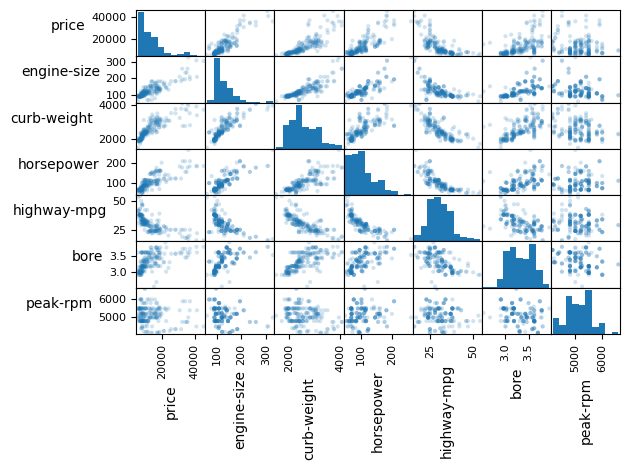

In [19]:
# Choosing some high and low correlated features to plot
corr_features =df[['price','engine-size', 'curb-weight', 'horsepower', 'highway-mpg', 'bore', 'peak-rpm']]

# shows the scatter plots for each pair of input features. The diagonal of the matrix shows each feature's histogram
axes = pd.plotting.scatter_matrix(corr_features, alpha=0.2)
# need to rotate axis labels so we can read them
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')

plt.tight_layout()
plt.gcf().subplots_adjust(wspace=0, hspace=0)
plt.show()
    

Variables highly correlated (pearson coefficient >= 0.75) with price : width, Curb-weight, Engine-size, Horsepower. Let's check their he P-value
(probability value that the correlation between these two variables is statistically significant).


In [53]:
import pandas as pd
from scipy import stats

# Select columns
df_pearson = df[['width', 'curb-weight', 'engine-size', 'horsepower']]

# loop for each column
for col in df_pearson.columns:
    pearson_coef, p_value = stats.pearsonr(df[col], df['price'])
    print(f"The Pearson Correlation Coefficient for {col} is {pearson_coef:.3f} with a P-value of {p_value:}")

The Pearson Correlation Coefficient for width is 0.751 with a P-value of 9.200335510480586e-38
The Pearson Correlation Coefficient for curb-weight is 0.834 with a P-value of 2.189577238893924e-53
The Pearson Correlation Coefficient for engine-size is 0.872 with a P-value of 9.26549162219869e-64
The Pearson Correlation Coefficient for horsepower is 0.810 with a P-value of 5.924001027592714e-48


**Since the p-value is < 0.001, the correlation between width, curb-weight, engine-size, horsepower and price is statistically significant.**

## 3. Understanding the relationship between variables

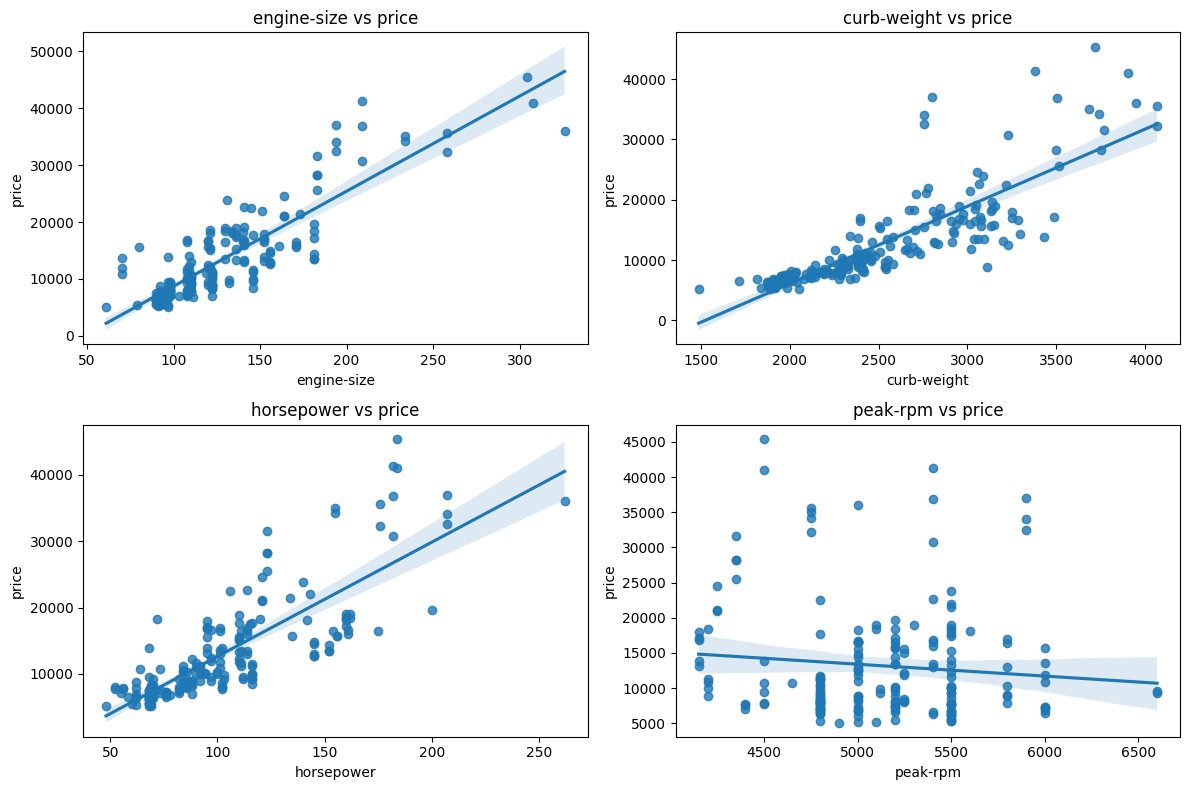

In [23]:
# Colunms to compare with "price"
cols = ["engine-size", "curb-weight", "horsepower", "peak-rpm"]

plt.figure(figsize=(12, 8))  # figure size

for i, col in enumerate(cols, 1):   # i = index, col = column name
    plt.subplot(2, 2, i)            # 2 rows, 2 colunms of subplots
    sns.regplot(x=col, y="price", data=df)
    plt.title(f"{col} vs price")

plt.tight_layout()
plt.show()

- As engine size increases, price also rises. This shows a strong positive correlation, making **engine size a reliable predictor of price**. Same for **curb-weight and horsepower**.
- Peak rpm shows little relation to price. The regression line is nearly flat and the data is widely scattered, so it’s not a reliable predictor.

## 4. Catgorical variables

Categorical variables are features that represent discrete groups or categories rather than continuous numerical values. They describe a 
characteristic or quality of a data unit (e.g., car brand, fuel type, body style). They can be stored as object or int64, and boxplots are a 
good way to visualize them.



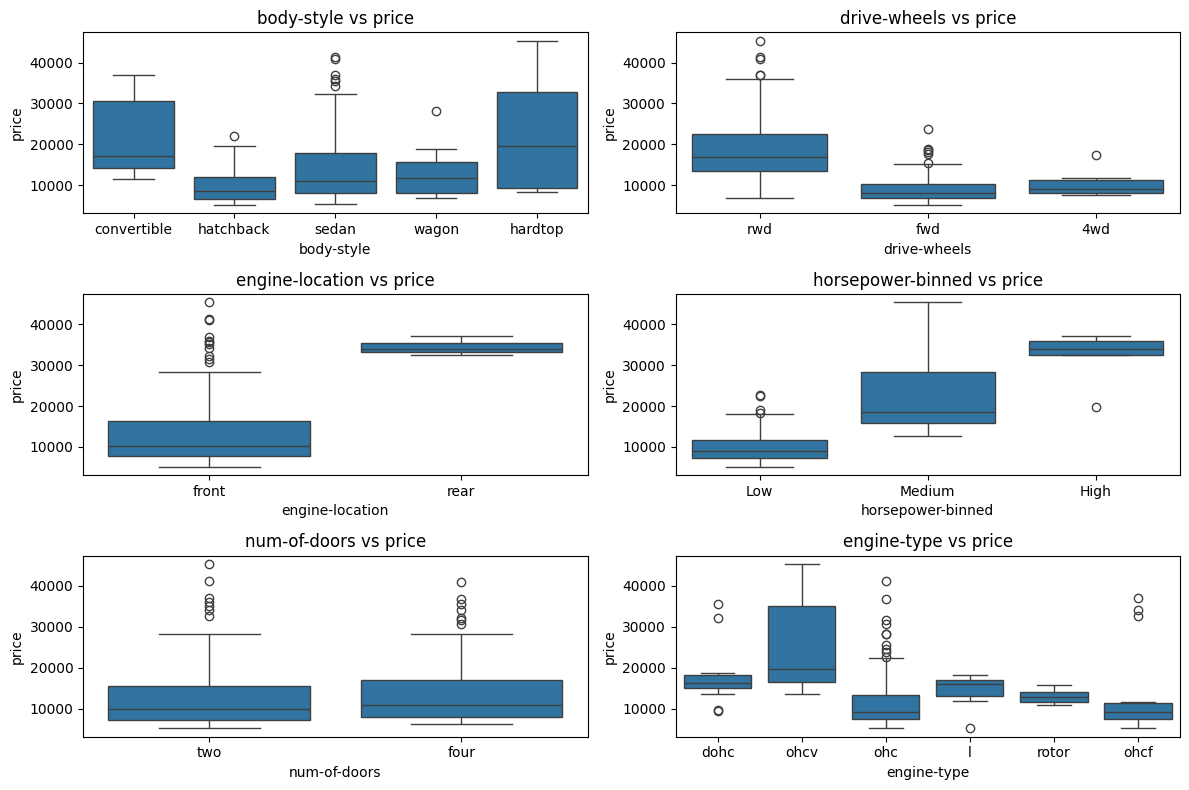

In [37]:
col_cat = df[['body-style', 'drive-wheels', 'engine-location', 'horsepower-binned', 'num-of-doors']]

plt.figure(figsize=(12, 8))
for i, col in enumerate(col_cat, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(x=col, y="price", data=df)
    plt.title(f"{col} vs price")
    
plt.tight_layout()
plt.show()

- Body‑style shows heavy overlap in price distributions, so it’s not a strong predictor.
- Price distributions vary across drive‑wheel categories, suggesting **drive‑wheels could be a useful predictor of price**.
- Price distributions differ clearly between front and rear engine‑location categories, making **engine‑location a potential predictor of price**.
Same for horsepower-binned but we already saw for the numerical value of horsepower that is well correlated.
- num-of-doors distribution shows heavy overlap in price distributions, so it’s not a strong predictor.

## 5. Check Skeweness for categorical variables

In [39]:
# check if we have balanced data
print(df['drive-wheels'].value_counts())
print(df['engine-location'].value_counts())

drive-wheels
fwd    118
rwd     75
4wd      8
Name: count, dtype: int64
engine-location
front    198
rear       3
Name: count, dtype: int64


Engine‑location is not a reliable predictor of price, since the dataset is highly imbalanced (only 3 rear‑engine cars vs. 198 front‑engine), making the result skewed and inconclusive

## 6. Basics of Grouping

Lest's say we want to know the average price by wheel drive, so how we do that? We will use the **"groupby"** method to group data by different 
categories.

In [40]:
df_group1 = df[['drive-wheels','body-style','price']] 
df_groupby = df_group1.groupby(['drive-wheels'], as_index=False).agg({'price':'mean'})
# if we want to calculate the mean on all numerical columns
#df_groupby = df_group1.groupby(['drive-wheels'], as_index=False).mean()
df_groupby

,drive-wheels,price
0,4wd,10241.000000
1,fwd,9244.779661
2,rwd,19757.613333


In [42]:
# Grouping by multiple variables 
df_groupby1 = df_group1.groupby(['drive-wheels', 'body-style'], as_index=False).mean()
df_groupby1

,drive-wheels,body-style,price
0,4wd,hatchback,7603.000000
1,4wd,sedan,12647.333333
2,4wd,wagon,9095.750000
3,fwd,convertible,11595.000000
4,fwd,hardtop,8249.000000
5,fwd,hatchback,8396.387755
6,fwd,sedan,9811.800000
7,fwd,wagon,9997.333333
8,rwd,convertible,23949.600000
9,rwd,hardtop,24202.714286


We will use **pivot table** to better represent and understand the data

In [45]:
grouped_pivot = df_groupby1.pivot(index='drive-wheels',columns='body-style')
grouped_pivot

price                                            \
body-style   convertible       hardtop     hatchback         sedan   
drive-wheels                                                         
4wd                  NaN           NaN   7603.000000  12647.333333   
fwd              11595.0   8249.000000   8396.387755   9811.800000   
rwd              23949.6  24202.714286  14337.777778  21711.833333   

                            
body-style           wagon  
drive-wheels                
4wd            9095.750000  
fwd            9997.333333  
rwd           16994.222222

We can fill the missing value by '0' or other value. Here we will fill with '0'

In [46]:
grouped_pivot = grouped_pivot.fillna(0)
grouped_pivot

price                                            \
body-style   convertible       hardtop     hatchback         sedan   
drive-wheels                                                         
4wd                  0.0      0.000000   7603.000000  12647.333333   
fwd              11595.0   8249.000000   8396.387755   9811.800000   
rwd              23949.6  24202.714286  14337.777778  21711.833333   

                            
body-style           wagon  
drive-wheels                
4wd            9095.750000  
fwd            9997.333333  
rwd           16994.222222

## 7. Categorical variables Visualization

Let's use a heat map to visualize the relationship between Body Style vs Price.

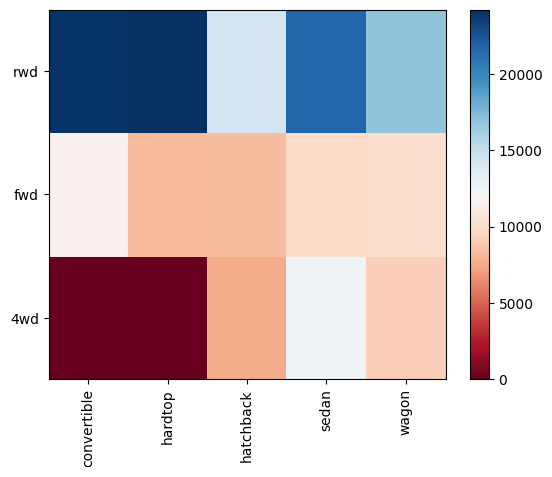

In [51]:
fig, ax = plt.subplots()
im = ax.pcolor(grouped_pivot, cmap='RdBu')

#label names
row_labels = grouped_pivot.columns.levels[1]
col_labels = grouped_pivot.index

#move ticks and labels to the center
ax.set_xticks(np.arange(grouped_pivot.shape[1]) + 0.5, minor=False)
ax.set_yticks(np.arange(grouped_pivot.shape[0]) + 0.5, minor=False)

#insert labels
ax.set_xticklabels(row_labels, minor=False)
ax.set_yticklabels(col_labels, minor=False)

#rotate label if too long
plt.xticks(rotation=90)

fig.colorbar(im)
plt.show()

## 8. Conclusion

We now have a clearer understanding of our dataset and which variables are most relevant for predicting car prices. We have narrowed the focus to 
the following key variables: 
- drive-wheels (categorical variable),
- width, Curb-weight, Engine-size, Horsepower (numerical variables).

We could also include additional numerical variables if we lower the threshold for the Pearson correlation retained to 0.5 , such as: wheel-base, length, width, bore, city-mpg, highway-mpg.

As we transition to building machine learning models to automate our analysis, incorporating variables that have a meaningful impact on the target will enhance the model’s predictive performance.